<a href="https://colab.research.google.com/github/Daksh-create349/UNet-Satellite-Segmentation/blob/main/Train_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata
import os


os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')


!kaggle datasets download -d franciscoescobar/satellite-images-of-water-bodies
!unzip -q satellite-images-of-water-bodies.zip -d water_data

Dataset URL: https://www.kaggle.com/datasets/franciscoescobar/satellite-images-of-water-bodies
License(s): CC-BY-NC-SA-4.0
satellite-images-of-water-bodies.zip: Skipping, found more recently modified local copy (use --force to force download)
replace water_data/Water Bodies Dataset/Images/water_body_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
!ls -R water_data | head -n 20

water_data:
Water Bodies Dataset

water_data/Water Bodies Dataset:
Images
Masks

water_data/Water Bodies Dataset/Images:
water_body_1000.jpg
water_body_1002.jpg
water_body_1003.jpg
water_body_1004.jpg
water_body_1006.jpg
water_body_1008.jpg
water_body_100.jpg
water_body_1010.jpg
water_body_1011.jpg
water_body_1014.jpg
water_body_1015.jpg
water_body_1018.jpg


In [ ]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class SatelliteWaterDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        # Get list of all image filenames
        self.images = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.img_dir, img_name)
        mask_path = os.path.join(self.mask_dir, img_name)

        # Load and resize to 128x128
        image = cv2.imread(img_path)
        image = cv2.resize(image, (128, 128)) / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (128, 128)) / 255.0

        # Convert to Tensors
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).unsqueeze(0).float()

        return image, mask

In [ ]:
img_folder = "water_data/Water Bodies Dataset/Images"
mask_folder = "water_data/Water Bodies Dataset/Masks"

# Now this will work because 'SatelliteWaterDataset' is defined above!
dataset = SatelliteWaterDataset(img_folder, mask_folder)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Success! Found {len(dataset)} image pairs.")


Success! Found 2841 image pairs.


In [ ]:
import torch.nn as nn

class MiniUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = nn.Conv2d(3, 32, 3, padding=1)
        self.e2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2)
        self.d1 = nn.Conv2d(64, 32, 3, padding=1)
        self.d2 = nn.Conv2d(32, 1, 3, padding=1)

    def forward(self, x):
        x = torch.relu(self.e1(x))
        x = self.pool(torch.relu(self.e2(x)))
        x = self.up(x)
        x = torch.relu(self.d1(x))
        return torch.sigmoid(self.d2(x))

model = MiniUNet().to('cuda')

In [ ]:
import torch.nn as nn


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MiniUNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print(f"Starting training on {device}...")


for epoch in range(10):
    model.train()
    epoch_loss = 0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)


        outputs = model(images)
        loss = criterion(outputs, masks)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}/10 | Average Loss: {epoch_loss/len(train_loader):.4f}")

print("Training Complete!")

Starting training on cuda...
Epoch 1/10 | Average Loss: 0.5267
Epoch 2/10 | Average Loss: 0.4587
Epoch 3/10 | Average Loss: 0.4284
Epoch 4/10 | Average Loss: 0.4139
Epoch 5/10 | Average Loss: 0.3994
Epoch 6/10 | Average Loss: 0.3929
Epoch 7/10 | Average Loss: 0.3872
Epoch 8/10 | Average Loss: 0.3806
Epoch 9/10 | Average Loss: 0.3770
Epoch 10/10 | Average Loss: 0.3744
Training Complete!


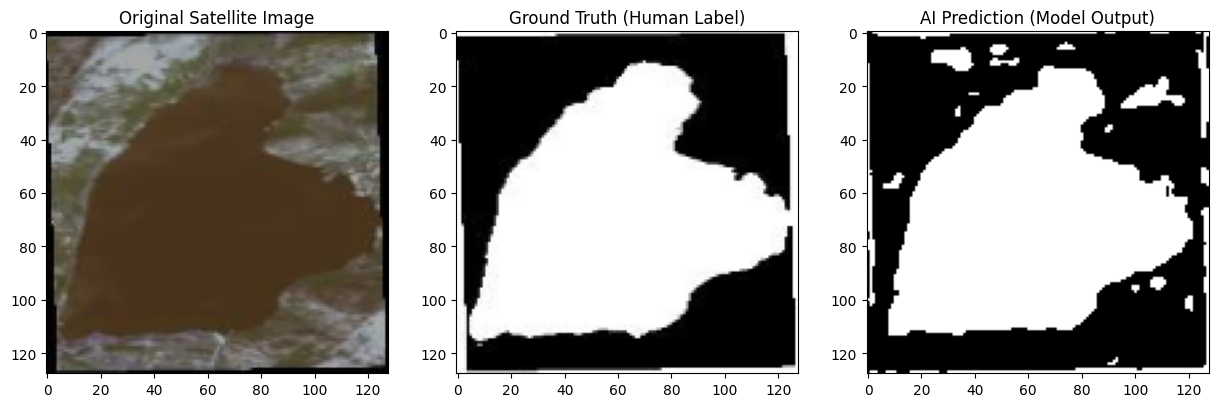

In [ ]:
import matplotlib.pyplot as plt


image, mask = dataset[100]
image_input = image.unsqueeze(0).to('cuda')


model.eval()
with torch.no_grad():
    prediction = model(image_input)


plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.title("Original Satellite Image")
plt.imshow(image.permute(1, 2, 0).cpu())

plt.subplot(1, 3, 2)
plt.title("Ground Truth (Human Label)")
plt.imshow(mask.squeeze().cpu(), cmap='gray')

plt.subplot(1, 3, 3)
plt.title("AI Prediction (Model Output)")

plt.imshow(prediction.cpu().squeeze() > 0.5, cmap='gray')

plt.show()

In [33]:
def check_accuracy(loader, model, device="cuda"):
    num_correct = 0
    num_pixels = 0
    model.eval()

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            preds = model(x)
            preds = (preds > 0.5).float()
            num_correct += (preds == y).sum()
            num_pixels += torch.numel(preds)

    print(f"Got {num_correct}/{num_pixels} with acc {num_correct/num_pixels*100:.2f}%")
    model.train()

check_accuracy(train_loader, model)

Got 32823472/46546944 with acc 70.52%
